In [1]:
import pandas as pd
import joblib

from scipy.sparse import load_npz

# loading labels
df = pd.read_csv("../data/preprocessed_moderation_data.csv")

# loading tfidf vectorizer
tfidf = joblib.load("../data/tfidf_vectorizer.pkl")

# loading tfidf matrices
X_train_tfidf = load_npz("../data/X_train_tfidf.npz")
X_test_tfidf = load_npz("../data/X_test_tfidf.npz")

# recreate labels using same split
from sklearn.model_selection import train_test_split

x = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("Training:", X_train_tfidf.shape, y_train.shape)
print("Testing:", X_test_tfidf.shape, y_test.shape)


Training: (131790, 10000) (131790,)
Testing: (32948, 10000) (32948,)


In [2]:
# training models
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [3]:
# making predictions
y_pred = nb_model.predict(X_test_tfidf)

print("Number of predictions:", len(y_pred))

Number of predictions: 32948


In [4]:
# evaluating model accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy: {accuracy: .4f}")
print(f"Model accuracy (%): {accuracy * 100: .2f}%")

Model accuracy:  0.9434
Model accuracy (%):  94.34%


In [5]:
# generating classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     abusive       0.90      0.52      0.66      3245
       clean       0.95      0.99      0.97     29572
        spam       1.00      0.12      0.22       131

    accuracy                           0.94     32948
   macro avg       0.95      0.54      0.61     32948
weighted avg       0.94      0.94      0.94     32948



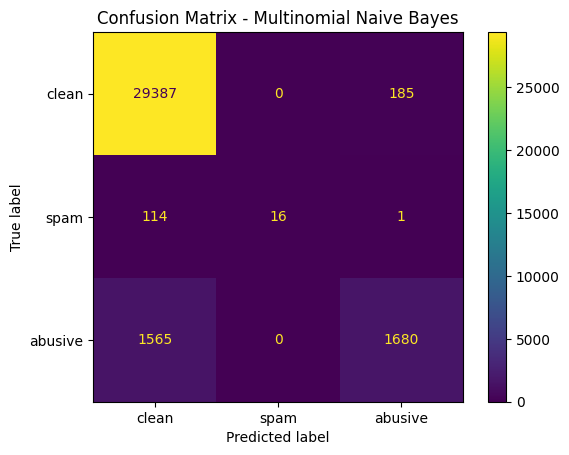

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["clean", "spam", "abusive"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(values_format="d")
plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [12]:
# generating predictions
y_pred_lr = lr_model.predict(X_test_tfidf)
print("Number of predictions:", len(y_pred_lr))

Number of predictions: 32948


In [14]:
# calculating accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Model accuracy: {accuracy_lr: .4f}")
print(f"Logistic Regression Model accuracy (%): {accuracy_lr * 100: .2f}%")

Logistic Regression Model accuracy:  0.9218
Logistic Regression Model accuracy (%):  92.18%


In [15]:
# generating report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

     abusive       0.58      0.85      0.69      3245
       clean       0.98      0.93      0.96     29572
        spam       0.56      0.91      0.69       131

    accuracy                           0.92     32948
   macro avg       0.71      0.90      0.78     32948
weighted avg       0.94      0.92      0.93     32948



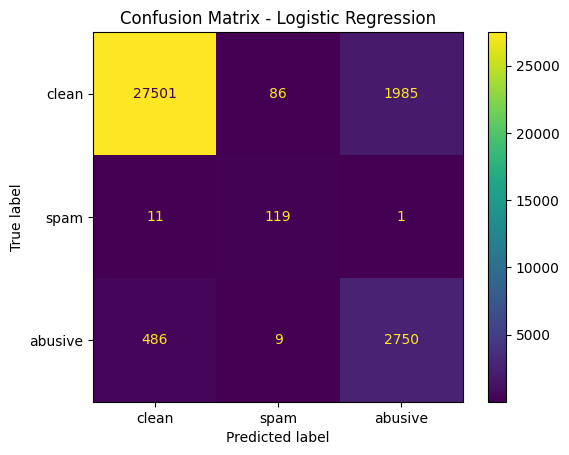

In [16]:
# generating logistic confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels)
disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=labels
)
disp_lr.plot(values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [19]:
# comparing models
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

metrics = []

for model_name, predictions in [
    ("Naive Bayes", y_pred),
    ("Logistic Regression", y_pred_lr)
]:
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    metrics.append({
        "Model": model_name,
        "Macro Precision": round(precision, 4),
        "Macro Recall": round(recall, 4),
        "Macro F1": round(f1, 4)
    })

comparison_df = pd.DataFrame(metrics)

comparison_df

,Model,Macro Precision,Macro Recall,Macro F1
0,Naive Bayes,0.9488,0.5445,0.6148
1,Logistic Regression,0.7063,0.8953,0.7781


In [20]:
# saving model
joblib.dump(nb_model, "../data/naive_bayes_model.pkl")
joblib.dump(lr_model, "../data/logistic_regression_model.pkl")

['../data/logistic_regression_model.pkl']

In [21]:
# testing messages
new_messages = [
    "Hello, how are you today?",
    "Congratulations! You won a free cash prize. Click now!",
    "You are so stupid and useless.",
    "Can we meet tomorrow for a discussion?",
    "WIN MONEY NOW!!!"
]

new_messages

['Hello, how are you today?',
 'Congratulations! You won a free cash prize. Click now!',
 'You are so stupid and useless.',
 'Can we meet tomorrow for a discussion?',
 'WIN MONEY NOW!!!']

In [24]:
# preprocessing new messages
import string

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = " ".join(text.split())
    return text

cleaned_messages = [clean_text(message) for message in new_messages]

print(cleaned_messages)

['hello how are you today', 'congratulations you won a free cash prize click now', 'you are so stupid and useless', 'can we meet tomorrow for a discussion', 'win money now']


In [25]:
# converting new messages to tfidf
new_messages_tfidf = tfidf.transform(cleaned_messages)
print(new_messages_tfidf.shape)

(5, 10000)


In [26]:
# predicting with both models
id = "predict_new"
nb_predictions = nb_model.predict(new_messages_tfidf)
lr_predictions = lr_model.predict(new_messages_tfidf)

results = pd.DataFrame({
    "Message": new_messages,
    "Navie Bayes Prediction": nb_predictions,
    "Logistic Regression Prediction": lr_predictions
})

results

,Message,Navie Bayes Prediction,Logistic Regression Prediction
0,"Hello, how are you today?",clean,clean
1,Congratulations! You won a free cash prize. Cl...,spam,spam
2,You are so stupid and useless.,abusive,abusive
3,Can we meet tomorrow for a discussion?,clean,clean
4,WIN MONEY NOW!!!,clean,spam


In [29]:
# building a reusable function for predictions

def moderate_message(message):
    # 1. Clean the message
    cleaned = clean_text(message)

    # 2. Convert to TF-IDF
    message_tfidf = tfidf.transform([cleaned])

    # 3. Predict using both models
    nb_prediction = str(nb_model.predict(message_tfidf)[0])
    lr_prediction = str(lr_model.predict(message_tfidf)[0])

    return {
        "message": message,
        "naive_bayes": nb_prediction,
        "logistic_regression": lr_prediction
    }

# testing the function
moderate_message("You won a free prize! Click now!")

{'message': 'You won a free prize! Click now!',
 'naive_bayes': 'clean',
 'logistic_regression': 'spam'}

In [30]:
# building batch moderation function for multiple messages
def moderate_messages(messages):
    # 1. Clean all messages
    cleaned = [clean_text(message) for message in messages]

    # 2. Convert all messages to TF-IDF
    messages_tfidf = tfidf.transform(cleaned)

    # 3. Predict using both models
    nb_predictions = nb_model.predict(messages_tfidf)
    lr_predictions = lr_model.predict(messages_tfidf)

    # 4. Create results table
    results = pd.DataFrame({
        "message": messages,
        "naive_bayes": nb_predictions.astype(str),
        "logistic_regression": lr_predictions.astype(str)
    })

    return results

# testing the batch moderation function
messages = [
    "Hello, how are you?",
    "You won a free cash prize!",
    "You are stupid and useless.",
    "Let's meet tomorrow.",
    "WIN MONEY NOW!!!",
    "Click this link to earn money quickly."
]

batch_results = moderate_messages(messages)

batch_results

,message,naive_bayes,logistic_regression
0,"Hello, how are you?",clean,clean
1,You won a free cash prize!,spam,spam
2,You are stupid and useless.,abusive,abusive
3,Let's meet tomorrow.,clean,clean
4,WIN MONEY NOW!!!,clean,spam
5,Click this link to earn money quickly.,clean,clean


In [32]:
# adding prediction confidence scores

def moderate_with_confidence(message):
    # 1. Clean the message
    cleaned = clean_text(message)

    # 2. Convert to TF-IDF
    message_tfidf = tfidf.transform([cleaned])

    # 3. Get predicted class and probabilities
    prediction = str(lr_model.predict(message_tfidf)[0])
    probabilities = lr_model.predict_proba(message_tfidf)[0]

    # 4. Get class probabilities
    class_probabilities = dict(
        zip(lr_model.classes_, probabilities)
    )

    return {
        "message": message,
        "prediction": prediction,
        "probabilities": class_probabilities
    }

# testing
result = moderate_with_confidence(
    "WIN MONEY NOW!!!"
)

print(result)

{'message': 'WIN MONEY NOW!!!', 'prediction': 'spam', 'probabilities': {'abusive': np.float64(0.008260513054193265), 'clean': np.float64(0.01354678829261902), 'spam': np.float64(0.9781926986531877)}}


In [33]:
# testing confidence on multiple messages

test_confidence_messages = [
    "Hello, how are you today?",
    "WIN MONEY NOW!!!",
    "You are stupid and useless.",
    "Click this link to earn money quickly.",
    "I love spending time with my friends."
]

for message in test_confidence_messages:
    result = moderate_with_confidence(message)

    print("\nMessage:", result["message"])
    print("Prediction:", result["prediction"])

    for label, probability in result["probabilities"].items():
        print(f"{label}: {probability:.2%}")


Message: Hello, how are you today?
Prediction: clean
abusive: 9.48%
clean: 83.28%
spam: 7.24%

Message: WIN MONEY NOW!!!
Prediction: spam
abusive: 0.83%
clean: 1.35%
spam: 97.82%

Message: You are stupid and useless.
Prediction: abusive
abusive: 100.00%
clean: 0.00%
spam: 0.00%

Message: Click this link to earn money quickly.
Prediction: clean
abusive: 10.45%
clean: 73.47%
spam: 16.09%

Message: I love spending time with my friends.
Prediction: clean
abusive: 20.26%
clean: 70.11%
spam: 9.63%
